In [1]:
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Audio, display

In [2]:
DATASET_PATH = Path("./speech_dataset")

## Dataset

Dataset: Toronto Emotional Speech Set (TESS)

Source:
https://tspace.library.utoronto.ca/handle/1807/24487

Reason for Selection

- Open-source speech emotion dataset
- High-quality recordings
- Balanced emotion classes
- Suitable for speech emotion recognition using deep learning
- Frequently used for benchmarking emotion classification models

Emotion Classes

1. angry
2. disgust
3. fear
4. happy
5. neutral
6. pleasant_surprise
7. sad

In [3]:
classes = sorted(
    [
        folder.name
        for folder in DATASET_PATH.iterdir()
        if folder.is_dir()
    ]
)

print(classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'pleasant_surprise', 'sad']


In [4]:
dataset_info = []

total_samples = 0

for emotion in classes:

    files = list((DATASET_PATH/emotion).glob("*.wav"))

    duration = 0

    sr = None

    for file in files:

        y, sr = librosa.load(file, sr=None)

        duration += len(y)/sr

    dataset_info.append({

        "Emotion": emotion,

        "Samples": len(files),

        "Duration (s)": round(duration,2),

        "Sample Rate": sr

    })

    total_samples += len(files)

dataset_df = pd.DataFrame(dataset_info)

dataset_df

,Emotion,Samples,Duration (s),Sample Rate
0,angry,200,313.92,24414
1,disgust,200,473.47,24414
2,fear,200,320.43,24414
3,happy,200,400.72,24414
4,neutral,200,403.96,24414
5,pleasant_surprise,200,408.13,24414
6,sad,200,507.16,24414


In [5]:
summary = pd.DataFrame({

    "Property":[

        "Dataset",

        "Number of Classes",

        "Total Samples",

        "Average Sample Rate"

    ],

    "Value":[

        "TESS",

        len(classes),

        total_samples,

        int(dataset_df["Sample Rate"].mode()[0])

    ]

})

summary

,Property,Value
0,Dataset,TESS
1,Number of Classes,7
2,Total Samples,1400
3,Average Sample Rate,24414


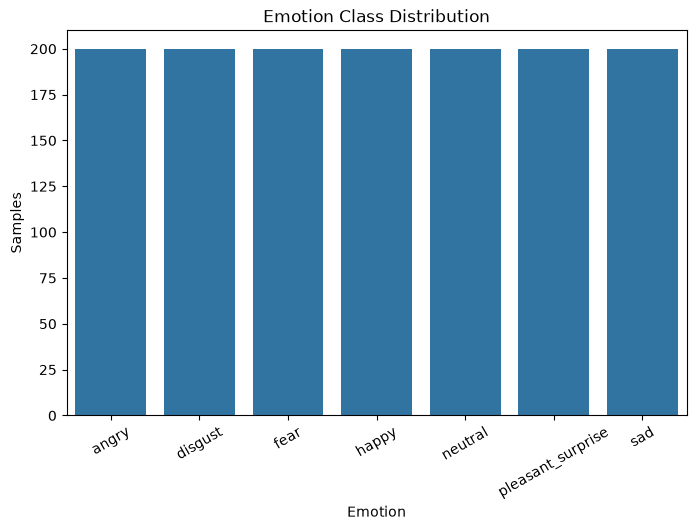

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=dataset_df,

    x="Emotion",

    y="Samples"

)

plt.xticks(rotation=30)

plt.title("Emotion Class Distribution")

plt.show()

In [7]:
example_files = {}

for emotion in classes:

    example_files[emotion] = random.choice(

        list((DATASET_PATH/emotion).glob("*.wav"))

    )

In [8]:
for emotion in classes:

    print(emotion)

    display(Audio(str(example_files[emotion])))

angry


disgust


fear


happy


neutral


pleasant_surprise


sad


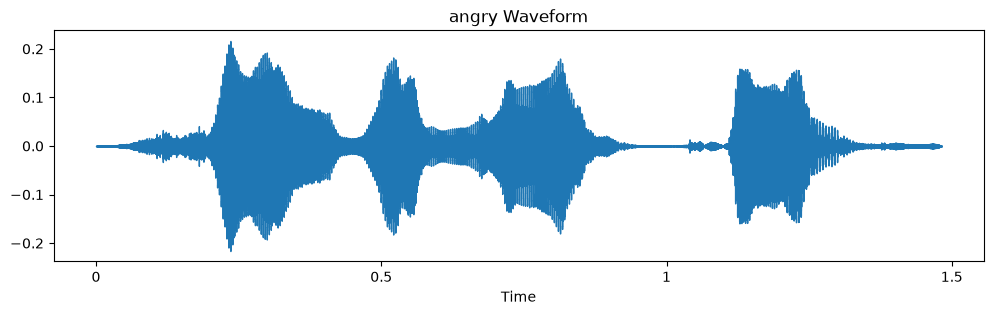

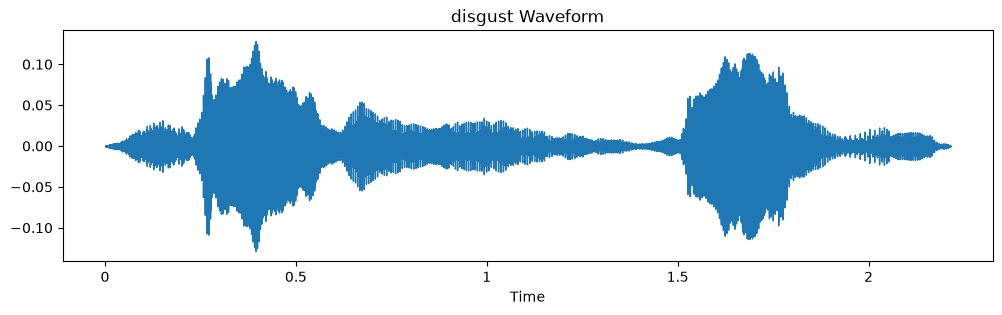

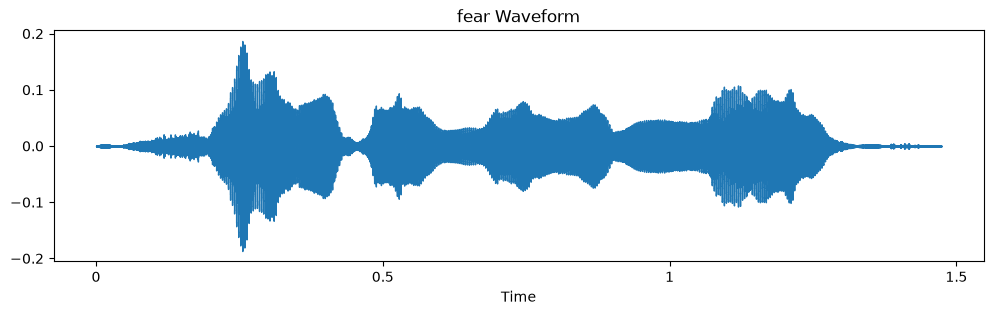

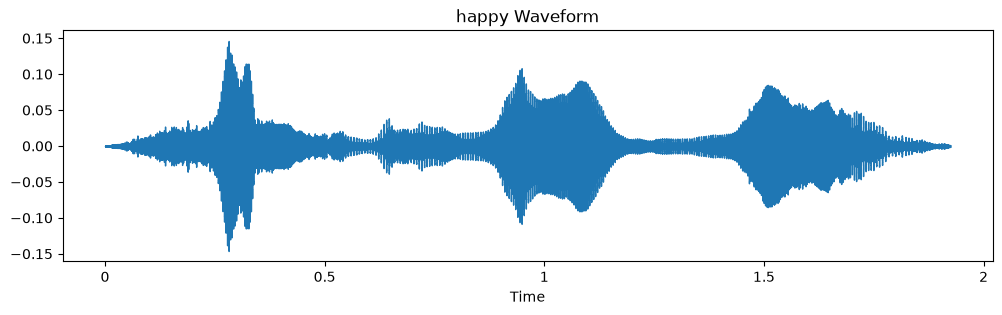

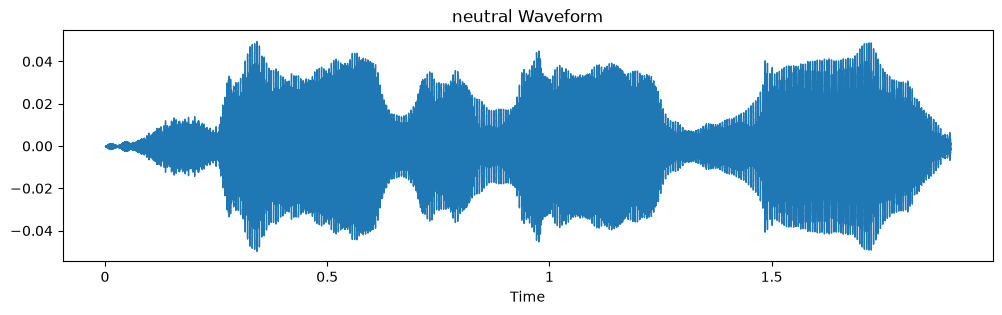

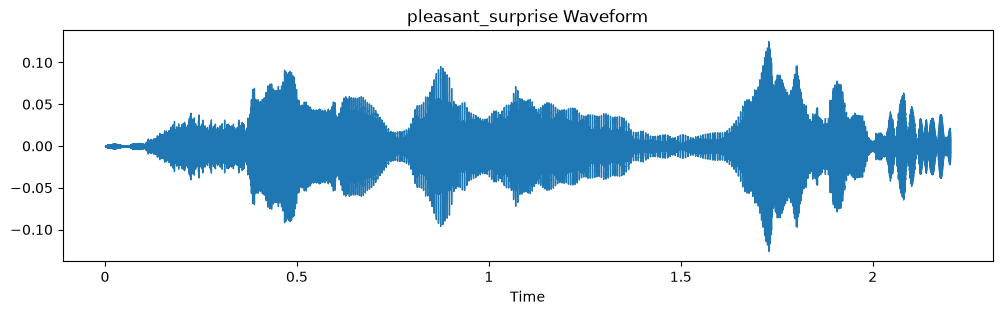

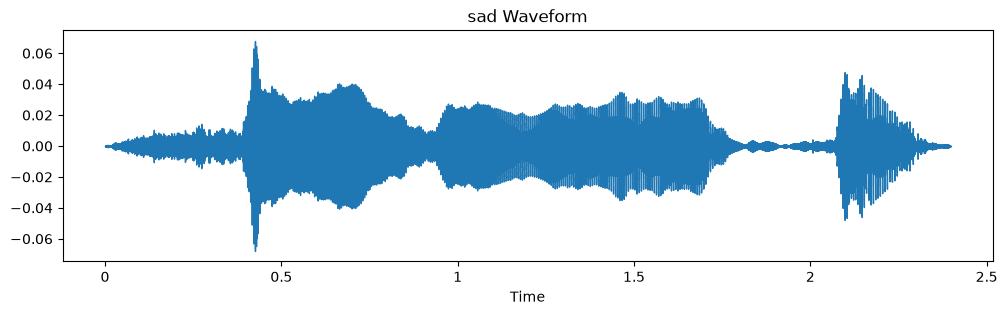

In [9]:
for emotion in classes:

    y, sr = librosa.load(

        example_files[emotion],

        sr=None

    )

    plt.figure(figsize=(12,3))

    librosa.display.waveshow(

        y,

        sr=sr

    )

    plt.title(f"{emotion} Waveform")

    plt.show()

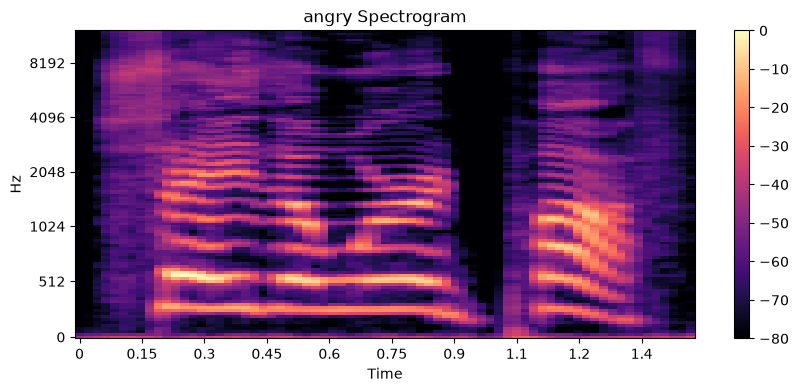

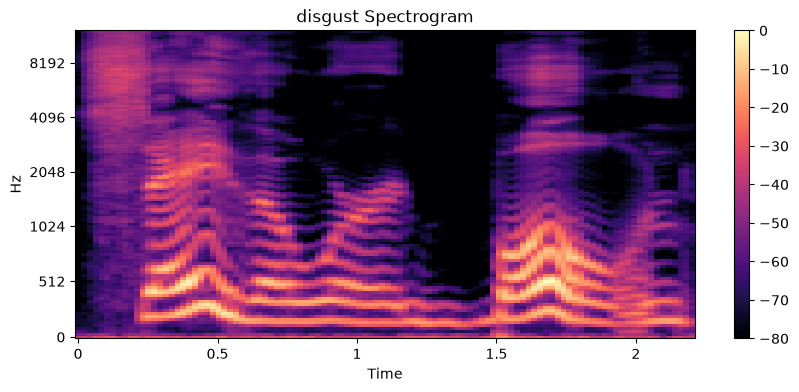

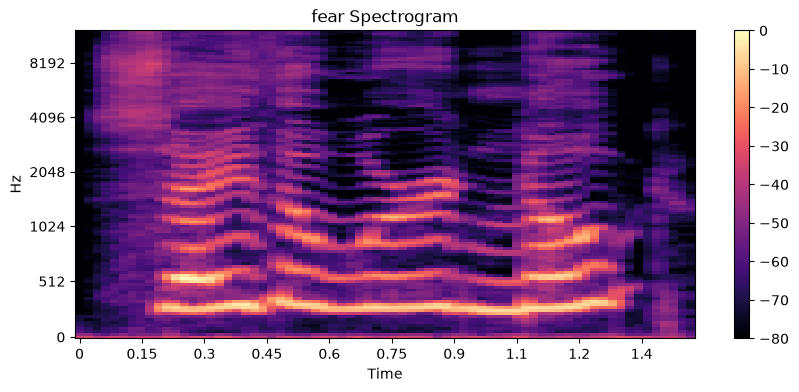

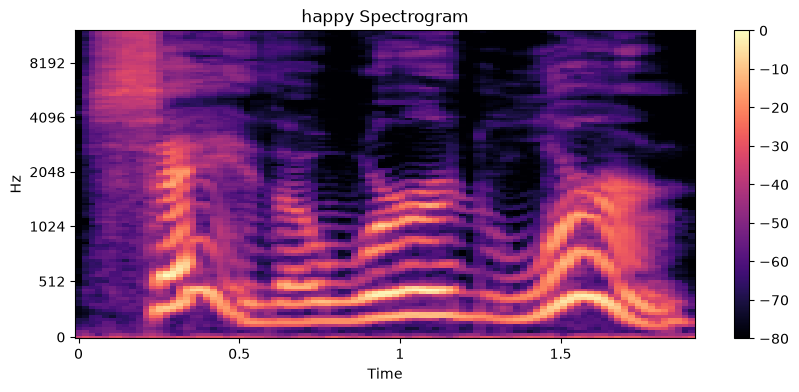

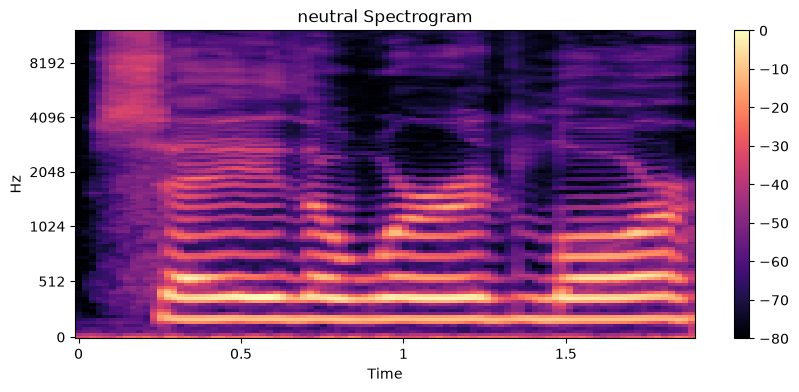

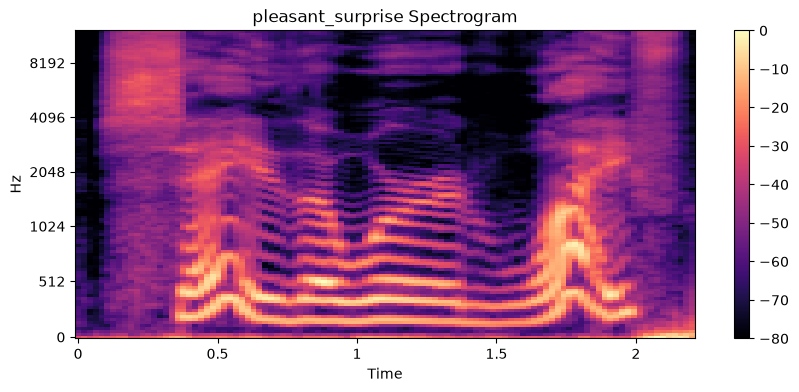

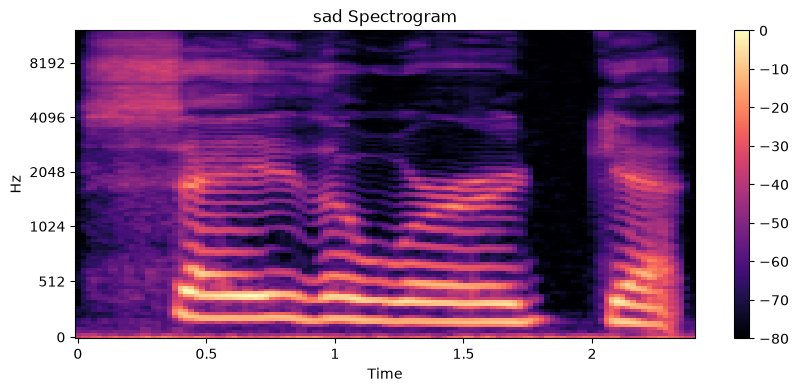

In [10]:
for emotion in classes:

    y, sr = librosa.load(

        example_files[emotion],

        sr=None

    )

    mel = librosa.feature.melspectrogram(

        y=y,

        sr=sr

    )

    mel_db = librosa.power_to_db(

        mel,

        ref=np.max

    )

    plt.figure(figsize=(10,4))

    librosa.display.specshow(

        mel_db,

        sr=sr,

        x_axis="time",

        y_axis="mel"

    )

    plt.colorbar()

    plt.title(f"{emotion} Spectrogram")

    plt.show()

In [11]:
class AudioPreprocessor:

    def __init__(

        self,

        sr=16000,

        duration=3,

        n_mfcc=40

    ):

        self.sr = sr

        self.duration = duration

        self.target_samples = sr*duration

        self.n_mfcc = n_mfcc

    def load_audio(self,path):

        y,sr = librosa.load(

            path,

            sr=self.sr,

            mono=True

        )

        return y

    def pad_or_truncate(self,y):

        if len(y)<self.target_samples:

            y = np.pad(

                y,

                (0,self.target_samples-len(y))

            )

        else:

            y = y[:self.target_samples]

        return y

    def extract_mfcc(self,y):

        mfcc = librosa.feature.mfcc(

            y=y,

            sr=self.sr,

            n_mfcc=self.n_mfcc

        )

        return mfcc.T.astype(np.float32)

    def process(self,path):

        y = self.load_audio(path)

        y = self.pad_or_truncate(y)

        mfcc = self.extract_mfcc(y)

        return mfcc

In [12]:
preprocessor = AudioPreprocessor()

sample = example_files["happy"]

mfcc = preprocessor.process(sample)

print(mfcc.shape)

(94, 40)


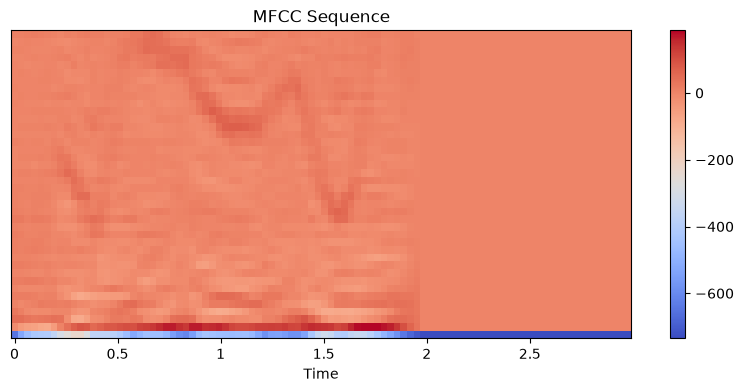

In [13]:
plt.figure(figsize=(10,4))

librosa.display.specshow(

    mfcc.T,

    x_axis="time",

    sr=16000

)

plt.colorbar()

plt.title("MFCC Sequence")

plt.show()

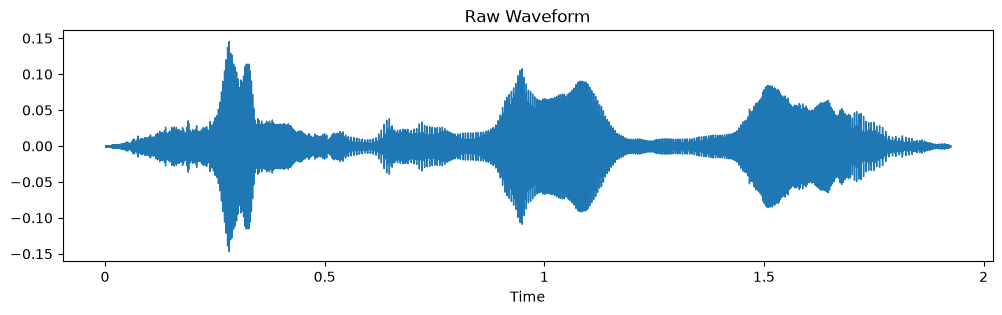

In [14]:
y, sr = librosa.load(sample, sr=None)

plt.figure(figsize=(12,3))

librosa.display.waveshow(y, sr=sr)

plt.title("Raw Waveform")

plt.show()

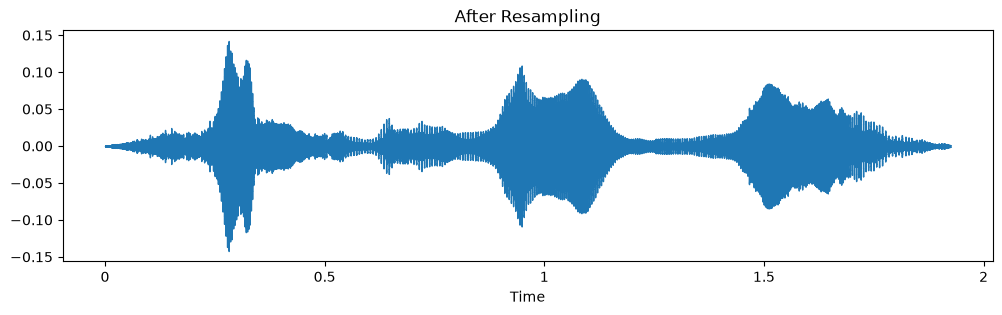

In [15]:
y = preprocessor.load_audio(sample)

plt.figure(figsize=(12,3))

librosa.display.waveshow(

    y,

    sr=16000

)

plt.title("After Resampling")

plt.show()

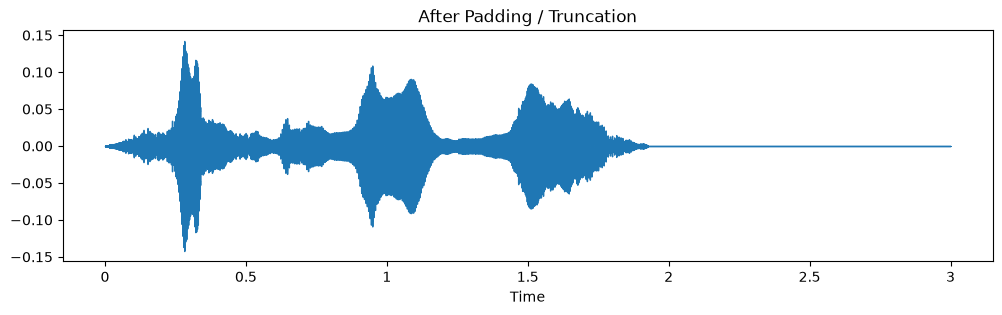

In [16]:
fixed = preprocessor.pad_or_truncate(y)

plt.figure(figsize=(12,3))

librosa.display.waveshow(

    fixed,

    sr=16000

)

plt.title("After Padding / Truncation")

plt.show()

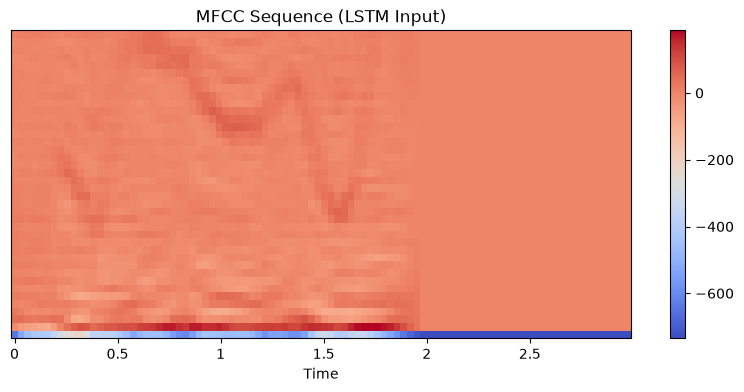

In [17]:
mfcc = preprocessor.extract_mfcc(fixed)

plt.figure(figsize=(10,4))

librosa.display.specshow(

    mfcc.T,

    x_axis="time",

    sr=16000

)

plt.colorbar()

plt.title("MFCC Sequence (LSTM Input)")

plt.show()

In [18]:
print("MFCC Shape:", mfcc.shape)

MFCC Shape: (94, 40)


In [19]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import numpy as np

In [20]:
file_paths = []
labels = []

emotion_to_idx = {
    emotion:i
    for i,emotion in enumerate(classes)
}

idx_to_emotion = {
    v:k
    for k,v in emotion_to_idx.items()
}

for emotion in classes:

    for file in (DATASET_PATH/emotion).glob("*.wav"):

        file_paths.append(str(file))

        labels.append(emotion_to_idx[emotion])

print("Total samples:",len(file_paths))

Total samples: 1400


In [21]:
train_files,test_files,train_labels,test_labels = train_test_split(

    file_paths,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels

)

train_files,val_files,train_labels,val_labels = train_test_split(

    train_files,

    train_labels,

    test_size=0.2,

    random_state=42,

    stratify=train_labels

)

print("Train:",len(train_files))
print("Validation:",len(val_files))
print("Test:",len(test_files))

Train: 896
Validation: 224
Test: 280


In [22]:
class EmotionDataset(Dataset):

    def __init__(

        self,

        file_paths,

        labels,

        preprocessor

    ):

        self.file_paths = file_paths
        self.labels = labels
        self.preprocessor = preprocessor

    def __len__(self):

        return len(self.file_paths)

    def __getitem__(self,idx):

        mfcc = self.preprocessor.process(

            self.file_paths[idx]

        )

        mfcc = torch.tensor(

            mfcc,

            dtype=torch.float32

        )

        label = torch.tensor(

            self.labels[idx],

            dtype=torch.long

        )

        return mfcc,label

In [23]:
train_dataset = EmotionDataset(

    train_files,

    train_labels,

    preprocessor

)

val_dataset = EmotionDataset(

    val_files,

    val_labels,

    preprocessor

)

test_dataset = EmotionDataset(

    test_files,

    test_labels,

    preprocessor

)

In [24]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

In [25]:
mfcc,label = train_dataset[0]

print(mfcc.shape)

torch.Size([94, 40])


In [26]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(device)

cpu


In [27]:
class EmotionLSTM(nn.Module):

    def __init__(

        self,

        input_size=40,

        hidden_size=128,

        num_layers=2,

        num_classes=7,

        dropout=0.3

    ):

        super().__init__()

        self.lstm = nn.LSTM(

            input_size=input_size,

            hidden_size=hidden_size,

            num_layers=num_layers,

            batch_first=True,

            dropout=dropout

        )

        self.fc = nn.Sequential(

            nn.Linear(hidden_size,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,num_classes)

        )

    def forward(self,x):

        output,(hidden,cell)=self.lstm(x)

        x=hidden[-1]

        x=self.fc(x)

        return x

In [28]:
model = EmotionLSTM(

    num_classes=len(classes)

).to(device)

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [31]:
def train_epoch(loader):

    model.train()

    running_loss = 0

    predictions = []

    targets = []

    for x,y in loader:

        x=x.to(device)
        y=y.to(device)

        optimizer.zero_grad()

        out=model(x)

        loss=criterion(out,y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred=out.argmax(1)

        predictions.extend(

            pred.cpu().numpy()

        )

        targets.extend(

            y.cpu().numpy()

        )

    acc = accuracy_score(

        targets,

        predictions

    )

    return running_loss/len(loader),acc

In [32]:
def validate(loader):

    model.eval()

    running_loss = 0

    predictions = []

    targets = []

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)
            y=y.to(device)

            out=model(x)

            loss=criterion(out,y)

            running_loss += loss.item()

            pred=out.argmax(1)

            predictions.extend(

                pred.cpu().numpy()

            )

            targets.extend(

                y.cpu().numpy()

            )

    acc = accuracy_score(

        targets,

        predictions

    )

    return running_loss/len(loader),acc

In [33]:
epochs = 30

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for epoch in range(epochs):

    tl,ta = train_epoch(train_loader)

    vl,va = validate(val_loader)

    train_loss.append(tl)
    val_loss.append(vl)

    train_acc.append(ta)
    val_acc.append(va)

    print(

        f"Epoch {epoch+1}/{epochs}"

        f"  Train Loss:{tl:.4f}"

        f"  Val Loss:{vl:.4f}"

        f"  Train Acc:{ta:.4f}"

        f"  Val Acc:{va:.4f}"

    )

Epoch 1/30  Train Loss:1.7680  Val Loss:1.3142  Train Acc:0.2667  Val Acc:0.4464
Epoch 2/30  Train Loss:1.1161  Val Loss:0.8919  Train Acc:0.4386  Val Acc:0.5491
Epoch 3/30  Train Loss:1.1554  Val Loss:0.9283  Train Acc:0.4286  Val Acc:0.6205
Epoch 4/30  Train Loss:0.8777  Val Loss:0.7260  Train Acc:0.5915  Val Acc:0.6875
Epoch 5/30  Train Loss:0.6851  Val Loss:0.6019  Train Acc:0.6730  Val Acc:0.6696
Epoch 6/30  Train Loss:0.4797  Val Loss:0.4000  Train Acc:0.7634  Val Acc:0.8080
Epoch 7/30  Train Loss:0.5497  Val Loss:0.3855  Train Acc:0.7533  Val Acc:0.8170
Epoch 8/30  Train Loss:0.3433  Val Loss:0.2839  Train Acc:0.8404  Val Acc:0.8438
Epoch 9/30  Train Loss:0.2558  Val Loss:0.2537  Train Acc:0.8504  Val Acc:0.8304
Epoch 10/30  Train Loss:0.2368  Val Loss:0.2716  Train Acc:0.8504  Val Acc:0.8482
Epoch 11/30  Train Loss:0.2915  Val Loss:0.2652  Train Acc:0.8471  Val Acc:0.8616
Epoch 12/30  Train Loss:0.2661  Val Loss:0.2989  Train Acc:0.8449  Val Acc:0.8393
Epoch 13/30  Train Loss:0

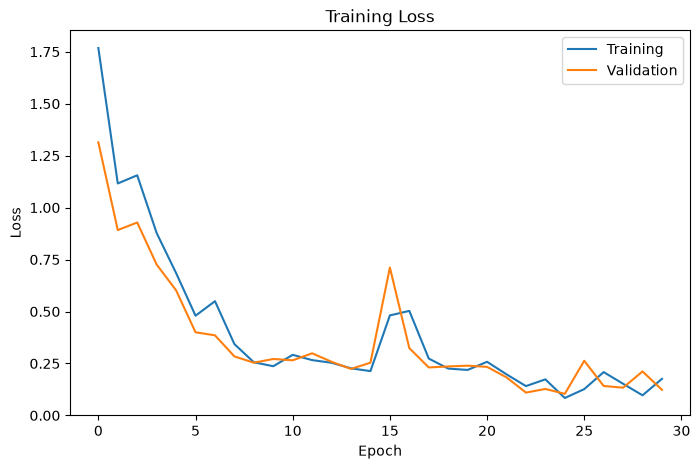

In [34]:
plt.figure(figsize=(8,5))

plt.plot(

    train_loss,

    label="Training"

)

plt.plot(

    val_loss,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

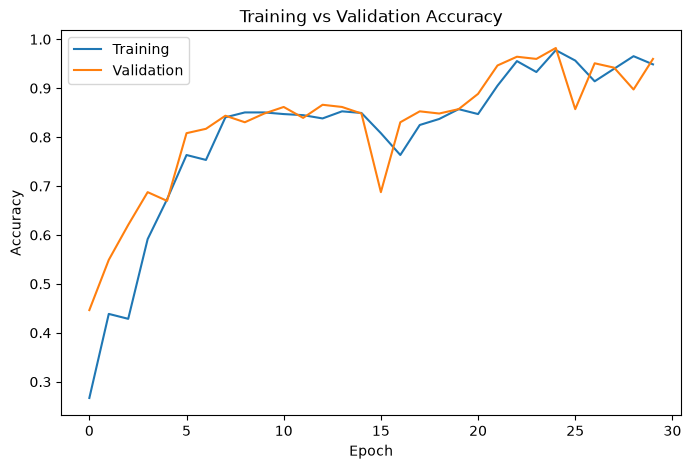

In [35]:
plt.figure(figsize=(8,5))

plt.plot(

    train_acc,

    label="Training"

)

plt.plot(

    val_acc,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [36]:
torch.save(

    model.state_dict(),

    "emotion_lstm.pth"

)

print("Model Saved.")

Model Saved.


In [37]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

In [38]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x)

        pred = output.argmax(1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

In [39]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9857
Precision : 0.9864
Recall : 0.9857
F1 Score : 0.9857


In [40]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

                   precision    recall  f1-score   support

            angry       1.00      1.00      1.00        40
          disgust       0.95      1.00      0.98        40
             fear       1.00      1.00      1.00        40
            happy       0.95      1.00      0.98        40
          neutral       1.00      1.00      1.00        40
pleasant_surprise       1.00      0.95      0.97        40
              sad       1.00      0.95      0.97        40

         accuracy                           0.99       280
        macro avg       0.99      0.99      0.99       280
     weighted avg       0.99      0.99      0.99       280



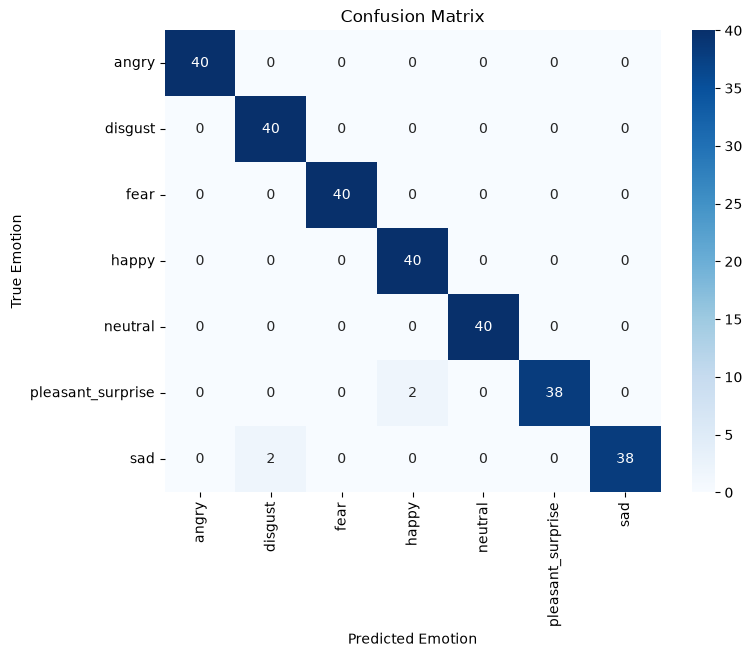

In [41]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Confusion Matrix")

plt.show()

In [42]:
predictions = []

model.eval()

with torch.no_grad():

    for idx in range(len(test_dataset)):

        mfcc, label = test_dataset[idx]

        output = model(
            mfcc.unsqueeze(0).to(device)
        )

        pred = output.argmax(1).item()

        predictions.append({

            "mfcc": mfcc,

            "true": label.item(),

            "pred": pred,

            "file": test_files[idx]

        })

In [43]:
correct = [
    p for p in predictions
    if p["true"] == p["pred"]
]

incorrect = [
    p for p in predictions
    if p["true"] != p["pred"]
]

print("Correct:", len(correct))
print("Incorrect:", len(incorrect))

Correct: 276
Incorrect: 4


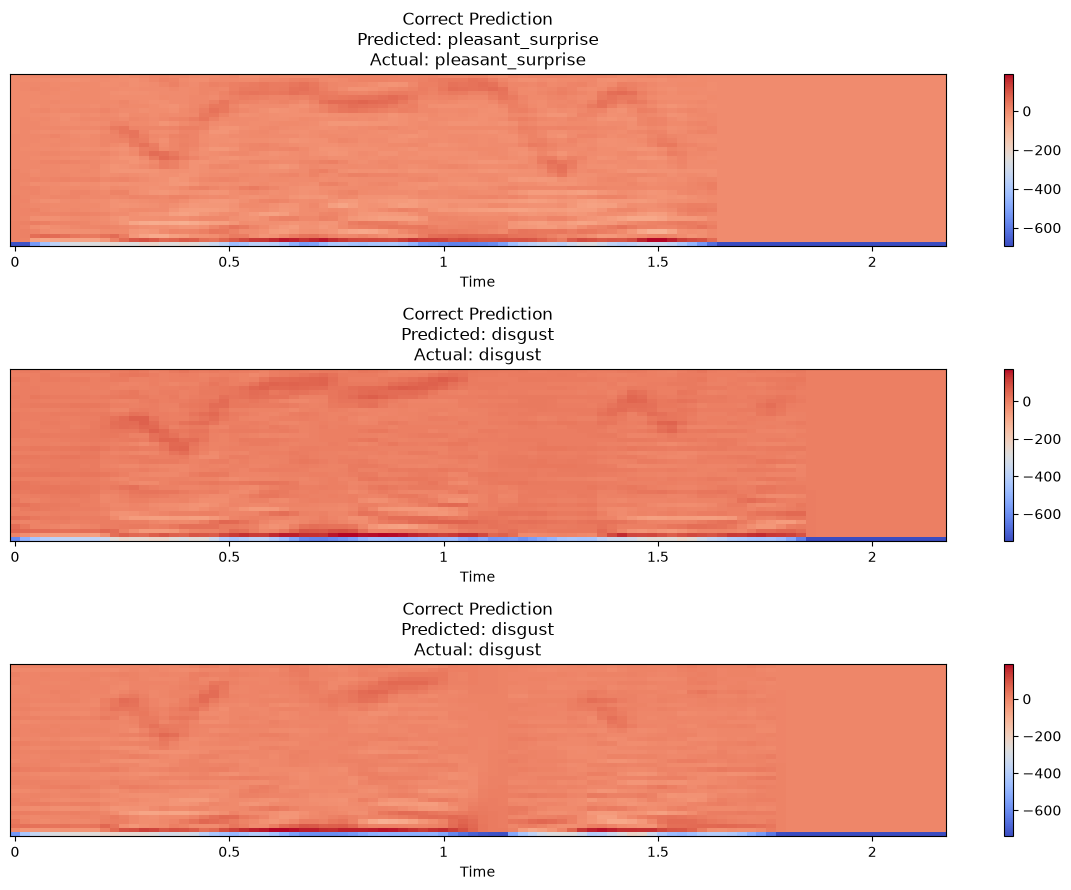

In [44]:
plt.figure(figsize=(12,9))

for i in range(min(3, len(correct))):

    plt.subplot(3,1,i+1)

    librosa.display.specshow(
        correct[i]["mfcc"].numpy().T,
        x_axis="time"
    )

    plt.colorbar()

    plt.title(
        f"Correct Prediction\n"
        f"Predicted: {idx_to_emotion[correct[i]['pred']]}\n"
        f"Actual: {idx_to_emotion[correct[i]['true']]}"
    )

plt.tight_layout()

plt.show()

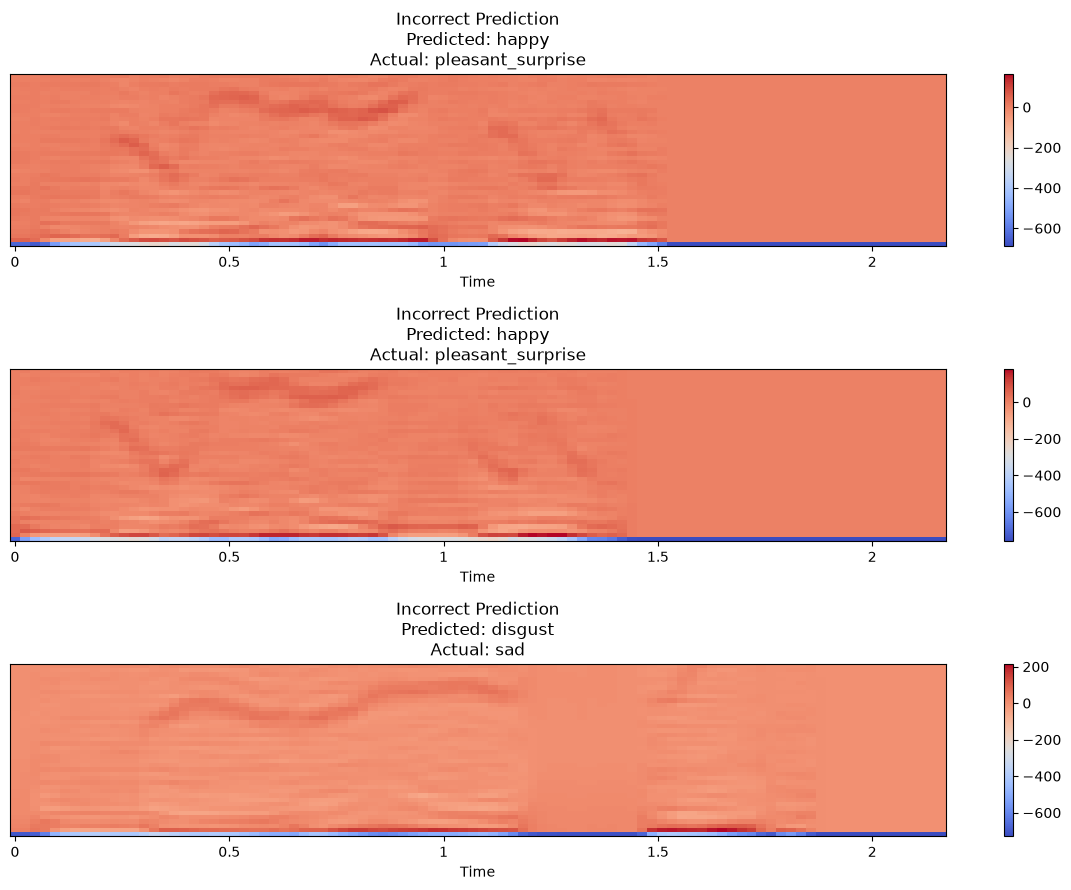

In [45]:
plt.figure(figsize=(12,9))

for i in range(min(3, len(incorrect))):

    plt.subplot(3,1,i+1)

    librosa.display.specshow(
        incorrect[i]["mfcc"].numpy().T,
        x_axis="time"
    )

    plt.colorbar()

    plt.title(
        f"Incorrect Prediction\n"
        f"Predicted: {idx_to_emotion[incorrect[i]['pred']]}\n"
        f"Actual: {idx_to_emotion[incorrect[i]['true']]}"
    )

plt.tight_layout()

plt.show()

In [46]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

results

,Metric,Value
0,Accuracy,0.985714
1,Precision,0.986395
2,Recall,0.985714
3,F1 Score,0.985705


In [47]:
torch.save(
    model.state_dict(),
    "tess_lstm_model.pth"
)

print("Model saved successfully.")

Model saved successfully.
